Nikodem Gronowski (169756)

Temat: Przewidywanie opóźnień komunikacji podstawie warunków pogodowych

Importowane biblioteki

In [113]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns

1. Pobieranie danych

In [114]:
kolumny = ['DAY_OF_MONTH', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME', 'DEP_DEL15', 'CANCELLED']
df = pd.read_csv('data/raw/Jan_2019_ontime.csv', usecols=kolumny)
df['DATE'] = pd.to_datetime('2019-01-' + df['DAY_OF_MONTH'].astype(str))

# Współrzędne lotniska ORD: Latitude 41.9742, Longitude -87.9073
df_chicago = df[df['ORIGIN'] == 'ORD'].copy()
print(f"Liczba lotów z Chicago w styczniu 2019: {len(df_chicago)}")

#API (Open-Meteo) dla Chicago na styczeń 2019
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 41.9742,
    "longitude": -87.9073,
    "start_date": "2019-01-01",
    "end_date": "2019-01-31",
    "daily": ["precipitation_sum", "snowfall_sum", "wind_speed_10m_max"],
    "timezone": "America/Chicago"
}

Liczba lotów z Chicago w styczniu 2019: 26216


In [115]:
response = requests.get(url, params=params)
weather_data = response.json()
df_weather = pd.DataFrame({
    'DATE': pd.to_datetime(weather_data['daily']['time']),
    'PRECIPITATION_MM': weather_data['daily']['precipitation_sum'],
    'SNOWFALL_CM': weather_data['daily']['snowfall_sum'],
    'WIND_SPEED_MAX_KMH': weather_data['daily']['wind_speed_10m_max']
})
display(df_weather.head())

,DATE,PRECIPITATION_MM,SNOWFALL_CM,WIND_SPEED_MAX_KMH
0,2019-01-01,0.3,0.14,14.2
1,2019-01-02,0.2,0.14,20.1
2,2019-01-03,0.0,0.00,20.1
3,2019-01-04,0.0,0.00,20.5
4,2019-01-05,0.0,0.00,18.6


 2. Zapisanie danych w Parquet file

In [116]:
#Merge
df_merged = pd.merge(df_chicago, df_weather, on='DATE', how='inner')
print(f"Liczba lotów po połączeniu z pogodą: {len(df_merged)}")
print("\nPołączone dane:")
display(df_merged.head())

Liczba lotów po połączeniu z pogodą: 26216

Połączone dane:


,DAY_OF_MONTH,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_TIME,DEP_DEL15,CANCELLED,DATE,PRECIPITATION_MM,SNOWFALL_CM,WIND_SPEED_MAX_KMH
0,1,AA,ORD,LGA,827.0,0.0,0.0,2019-01-01,0.3,0.14,14.2
1,1,AA,ORD,LGA,1300.0,1.0,0.0,2019-01-01,0.3,0.14,14.2
2,1,AA,ORD,SJU,828.0,0.0,0.0,2019-01-01,0.3,0.14,14.2
3,1,AA,ORD,LGA,625.0,0.0,0.0,2019-01-01,0.3,0.14,14.2
4,1,AA,ORD,PHL,651.0,0.0,0.0,2019-01-01,0.3,0.14,14.2


In [117]:
sciezka_parquet = 'data/processed/loty_pogoda.parquet'
df_merged.to_parquet(sciezka_parquet)
print(f"Zapisano do pliku Parquet w: {sciezka_parquet}")

Zapisano do pliku Parquet w: data/processed/loty_pogoda.parquet


3. Przygotowanie danych

In [118]:
df_merged = pd.read_parquet('data/processed/loty_pogoda.parquet')
df_clean = df_merged[df_merged['CANCELLED'] == 0.0].copy()
kdu = ['CANCELLED', 'ORIGIN', 'DATE', 'DEP_TIME']
df_clean = df_clean.drop(columns=kdu)
df_clean = df_clean.dropna(subset=['DEP_DEL15'])
#linie lotnicze i cel lotu na format binarny
df_encoded = pd.get_dummies(df_clean, columns=['OP_UNIQUE_CARRIER', 'DEST'], drop_first=True)
#Skalowanie pogody
scaler = StandardScaler()
kpg = ['PRECIPITATION_MM', 'SNOWFALL_CM', 'WIND_SPEED_MAX_KMH']
df_encoded[kpg] = scaler.fit_transform(df_encoded[kpg])

In [119]:
print(f"Liczba wierszy przed czyszczeniem: {len(df_merged)}")
print(f"Liczba wierszy po czyszczeniu: {len(df_encoded)}")
print(f"Liczba cech po One Hot Encoding: {len(df_encoded.columns)}")

Liczba wierszy przed czyszczeniem: 26216
Liczba wierszy po czyszczeniu: 23400
Liczba cech po One Hot Encoding: 170


4. Zapisz przygotowanych danych

In [120]:
print("\nPróbka gotowych danych:")
display(df_encoded.head())
df_encoded.to_parquet('data/processed/loty_gotowe_do_treningu.parquet')
df = pd.read_parquet('data/processed/loty_gotowe_do_treningu.parquet')
proporcje = df['DEP_DEL15'].value_counts(normalize=True) * 100
print(f"Loty na czas (0.0): {proporcje[0]:.2f}%")
print(f"Loty opóźnione (1.0): {proporcje[1]:.2f}%")


Próbka gotowych danych:


,DAY_OF_MONTH,DEP_DEL15,PRECIPITATION_MM,SNOWFALL_CM,WIND_SPEED_MAX_KMH,OP_UNIQUE_CARRIER_AA,OP_UNIQUE_CARRIER_AS,OP_UNIQUE_CARRIER_B6,OP_UNIQUE_CARRIER_DL,OP_UNIQUE_CARRIER_EV,...,DEST_SUX,DEST_SYR,DEST_TOL,DEST_TPA,DEST_TUL,DEST_TUS,DEST_TVC,DEST_TYS,DEST_UIN,DEST_XNA
0,1,0.0,-0.402736,-0.367105,-1.074304,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,1.0,-0.402736,-0.367105,-1.074304,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,0.0,-0.402736,-0.367105,-1.074304,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,0.0,-0.402736,-0.367105,-1.074304,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,0.0,-0.402736,-0.367105,-1.074304,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Loty na czas (0.0): 71.80%
Loty opóźnione (1.0): 28.20%


5. Uruchomienie treningu

In [121]:
# cechy (X) i zmienna docelowa (y)
y = df['DEP_DEL15']
X = df.drop(columns=['DEP_DEL15'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [122]:
y_pred = model.predict(X_test)
print("\nRaport klasyfikacji na danych testowych:")
print(classification_report(y_test, y_pred))


Raport klasyfikacji na danych testowych:
              precision    recall  f1-score   support

         0.0       0.81      0.70      0.75      3336
         1.0       0.45      0.60      0.51      1344

    accuracy                           0.67      4680
   macro avg       0.63      0.65      0.63      4680
weighted avg       0.71      0.67      0.68      4680



C:\Users\nikod\AppData\Local\Temp\ipykernel_904\863211681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pogoda_importances, x='Waznosc', y='Cecha', palette='Blues_r')


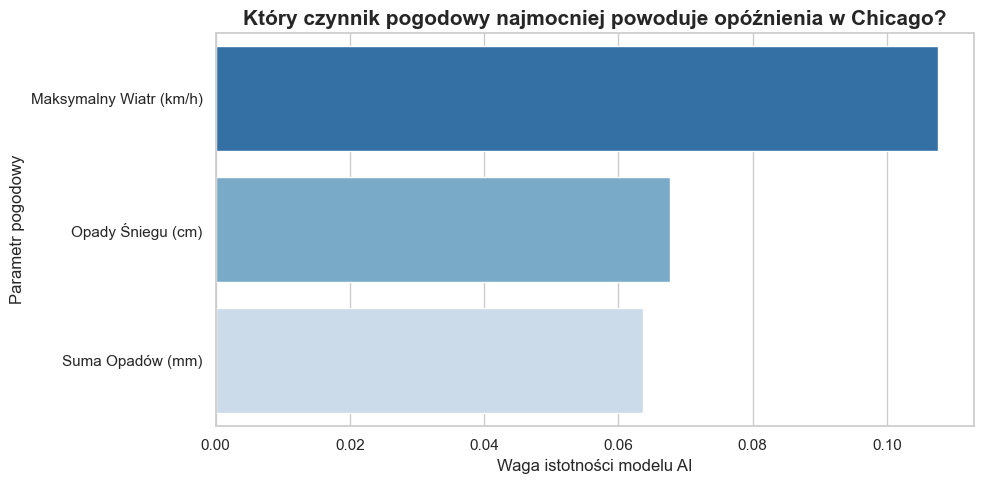

In [123]:
importances = model.feature_importances_
feature_df = pd.DataFrame({'Cecha': X.columns, 'Waznosc': importances})
cechy_pogodowe = ['WIND_SPEED_MAX_KMH', 'SNOWFALL_CM', 'PRECIPITATION_MM']

pogoda_importances = feature_df[feature_df['Cecha'].isin(cechy_pogodowe)].sort_values(by='Waznosc', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=pogoda_importances, x='Waznosc', y='Cecha', palette='Blues_r')

plt.title('Który czynnik pogodowy najmocniej powoduje opóźnienia w Chicago?', fontsize=15, fontweight='bold')
plt.xlabel('Waga istotności modelu AI', fontsize=12)
plt.ylabel('Parametr pogodowy', fontsize=12)
plt.yticks(ticks=[0, 1, 2], labels=[
    'Maksymalny Wiatr (km/h)',
    'Opady Śniegu (cm)',
    'Suma Opadów (mm)'
])
plt.tight_layout()
plt.show()

C:\Users\nikod\AppData\Local\Temp\ipykernel_904\2020643138.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Status', y='WIND_SPEED_MAX_KMH', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
C:\Users\nikod\AppData\Local\Temp\ipykernel_904\2020643138.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Status', y='SNOWFALL_CM', palette=['#2ecc71', '#e74c3c'], ax=axes[1])


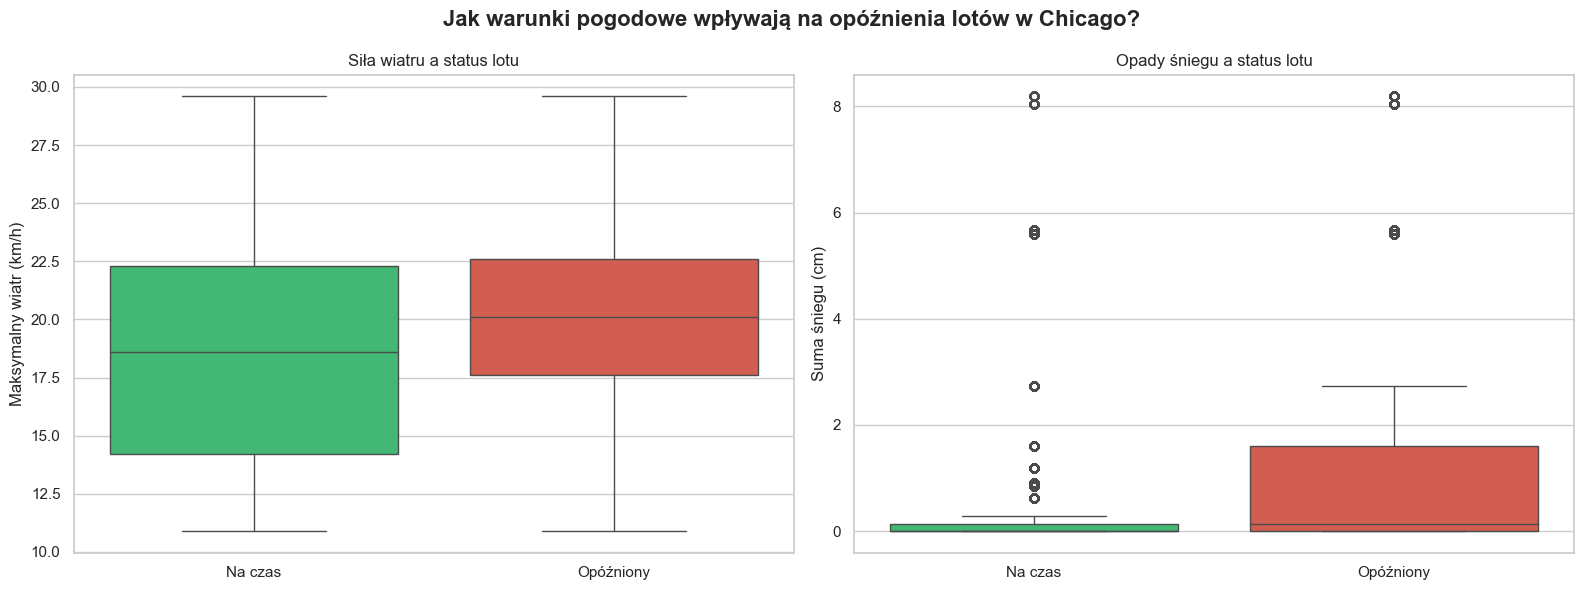

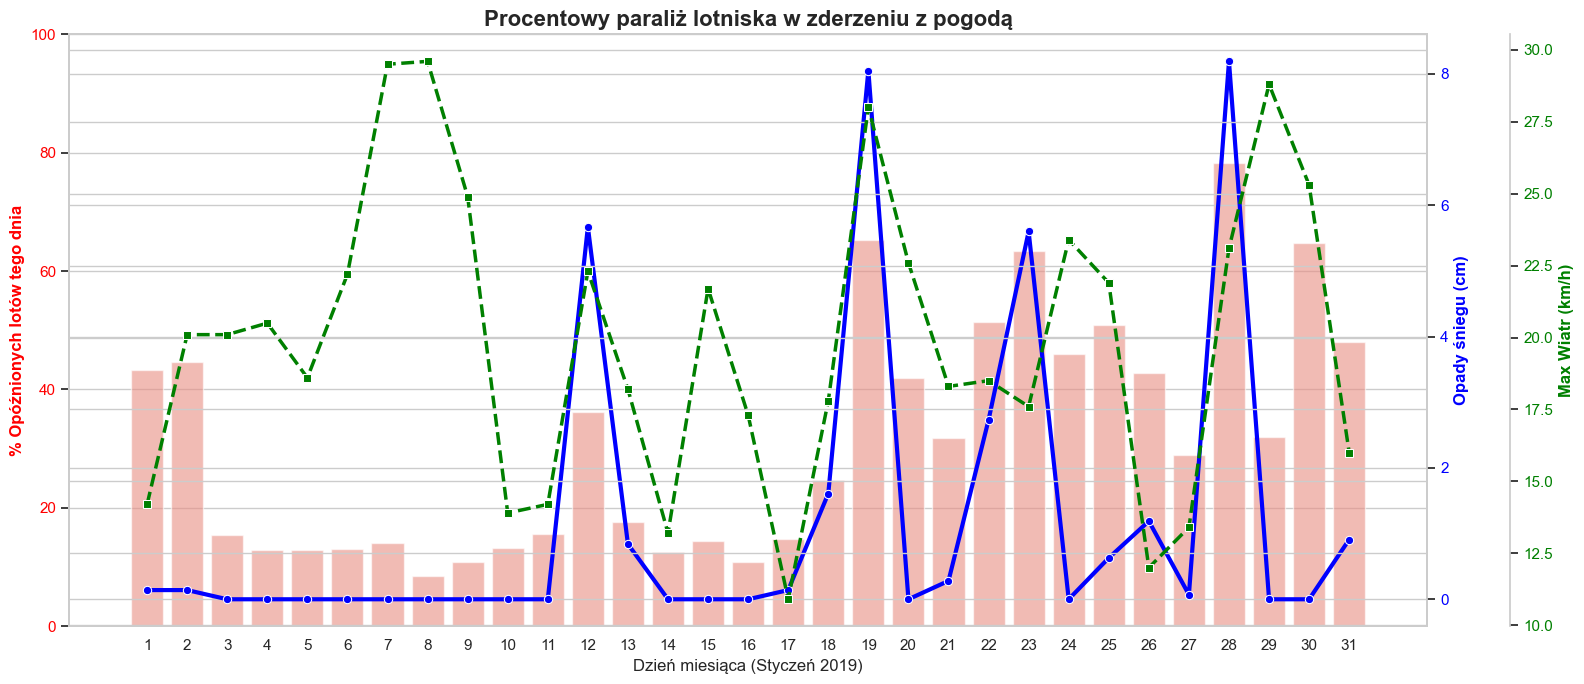

C:\Users\nikod\AppData\Local\Temp\ipykernel_904\2020643138.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=linie_opoznienia, x='OP_UNIQUE_CARRIER', y='Procent_Opoznien', palette='viridis')


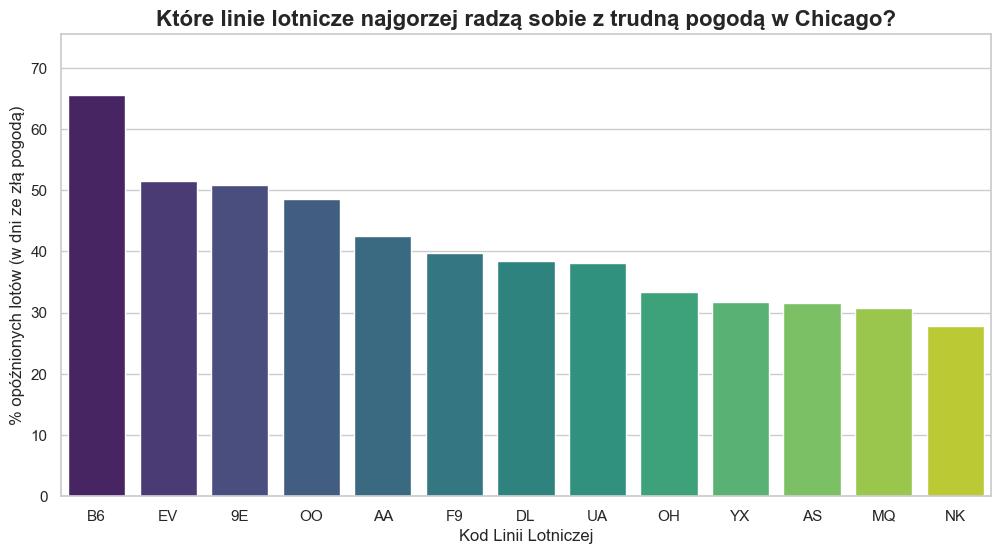

In [124]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
df_viz = pd.read_parquet('data/processed/loty_pogoda.parquet')
df_viz = df_viz[df_viz['CANCELLED'] == 0].dropna(subset=['DEP_DEL15']).copy()
df_viz['Status'] = np.where(df_viz['DEP_DEL15'] == 1, 'Opóźniony', 'Na czas')

#1. PIERWSZY WYKRES
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Jak warunki pogodowe wpływają na opóźnienia lotów w Chicago?', fontsize=16, fontweight='bold')
#Wiatr
sns.boxplot(data=df_viz, x='Status', y='WIND_SPEED_MAX_KMH', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Siła wiatru a status lotu')
axes[0].set_ylabel('Maksymalny wiatr (km/h)')
axes[0].set_xlabel('')
#Śnieg
sns.boxplot(data=df_viz, x='Status', y='SNOWFALL_CM', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Opady śniegu a status lotu')
axes[1].set_ylabel('Suma śniegu (cm)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

#2. OŚ CZASU
dzienne_statystyki = df_viz.groupby('DAY_OF_MONTH').agg(
    Wszystkie_Loty=('DEP_DEL15', 'count'),
    Liczba_Opoznien=('DEP_DEL15', 'sum'),
    Snieg_cm=('SNOWFALL_CM', 'max'),
    Wiatr_kmh=('WIND_SPEED_MAX_KMH', 'max')
).reset_index()

dzienne_statystyki['Procent_Opoznien'] = (dzienne_statystyki['Liczba_Opoznien'] / dzienne_statystyki['Wszystkie_Loty']) * 100

fig, ax1 = plt.subplots(figsize=(16, 7))

#Wykres słupkowy dla opóźnień
sns.barplot(data=dzienne_statystyki, x='DAY_OF_MONTH', y='Procent_Opoznien', color='salmon', alpha=0.6, ax=ax1)
ax1.set_xlabel('Dzień miesiąca (Styczeń 2019)', fontsize=12)
ax1.set_ylabel('% Opóźnionych lotów tego dnia', color='red', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(0, 100) # Oś procentowa od 0 do 100%

#Wykres liniowy dla opadów śniegu
ax2 = ax1.twinx()
sns.lineplot(data=dzienne_statystyki, x=dzienne_statystyki.index, y='Snieg_cm', color='blue', marker='o', linewidth=3, ax=ax2)
ax2.set_ylabel('Opady śniegu (cm)', color='blue', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

#Wykres liniowy dla siły wiatru
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
sns.lineplot(data=dzienne_statystyki, x=dzienne_statystyki.index, y='Wiatr_kmh', color='green', marker='s', linestyle='--', linewidth=2.5, ax=ax3)
ax3.set_ylabel('Max Wiatr (km/h)', color='green', fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='green')

plt.title('Procentowy paraliż lotniska w zderzeniu z pogodą', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

#3. KONTEKST BIZNESOWY
zla_pogoda = df_viz[(df_viz['WIND_SPEED_MAX_KMH'] > 30) | (df_viz['SNOWFALL_CM'] > 0)]
linie_opoznienia = zla_pogoda.groupby('OP_UNIQUE_CARRIER')['DEP_DEL15'].mean().reset_index()
linie_opoznienia['Procent_Opoznien'] = linie_opoznienia['DEP_DEL15'] * 100
linie_opoznienia = linie_opoznienia.sort_values('Procent_Opoznien', ascending=False)
#---------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=linie_opoznienia, x='OP_UNIQUE_CARRIER', y='Procent_Opoznien', palette='viridis')
plt.title('Które linie lotnicze najgorzej radzą sobie z trudną pogodą w Chicago?', fontsize=16, fontweight='bold')
plt.ylabel('% opóźnionych lotów (w dni ze złą pogodą)')
plt.xlabel('Kod Linii Lotniczej')
plt.ylim(0, max(linie_opoznienia['Procent_Opoznien']) + 10)
plt.show()

6. Podsumowanie

Po przeprowadzeniu dogłębnej analizy można dojść do wniosku że warunki pogodowe bezpośrednio odzwierciedlają się w opóźnieniach wylotu samolotów z lotniska. Dodatkową statystyką która byłaby w stanie dopełnić badanie jest ilość lotów odwołanych ze względu na warunki pogodowe. Patrząc brane pod uwage parametry pogodowe jesteśmy w stanie zauważyć że silny wiatr występował w większym stopniu niż opady śniegu, ale potrafiły one też iść w parze. Ponadto zauważamy że ich występowanie w bardzo podobnie wpływa na opóźnienia.


W samym zbiorze Kaggle największą wagę posiada silny wiatr z dużą przewagą nad opadami śniegu.